# Gamer Personas — K-Means Clustering

**Goal:** Use unsupervised K-Means clustering to discover natural "Gamer Personas" from behavioral
and lifestyle data — without assuming any predefined groupings.

**Dataset:** Gaming and Mental Health (1,000 respondents, 27 features)

**Pipeline:**
1. Data audit — understand every column, every missing value
2. Feature selection — behavior-driven, not demographic
3. Preprocessing — impute → encode → drop zero-variance → scale
4. PCA — reduce dimensionality, retain 80 % of variance
5. Select K — Elbow + Silhouette
6. Fit K-Means
7. Visualise clusters
8. Profile and name each persona

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 40)

## 2. Load Data & Full Audit

Before touching a single feature we audit every column: dtype, missing rate, and unique values.
This drives every downstream decision.

In [2]:
df = pd.read_csv('../data/Gaming and Mental Health.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n')
df.head(3)

Shape: 1,000 rows × 27 columns



,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,Below Average,1.25,NaN,Anxious,Never,True,False,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,Good,3.75,2.0,Irritable,Often,False,False,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,Poor,NaN,9.0,Irritable,Rarely,True,True,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe


In [3]:
# ── dtype + missing value summary ──────────────────────────────────────────
audit = pd.DataFrame({
    'dtype':        df.dtypes,
    'n_missing':    df.isnull().sum(),
    'pct_missing':  (df.isnull().mean() * 100).round(1),
    'n_unique':     df.nunique(),
    'sample_values': {c: df[c].dropna().unique()[:4].tolist() for c in df.columns},
})
print('=== Column Audit ===')
audit

=== Column Audit ===


,dtype,n_missing,pct_missing,n_unique,sample_values
record_id,str,0,0.0,1000,"[GD0001, GD0002, GD0003, GD0004]"
age,int64,0,0.0,23,"[17, 21, 23, 20]"
gender,str,0,0.0,3,"[Male, Female, Other]"
daily_gaming_hours,float64,0,0.0,132,"[11.1, 3.0, 7.6, 7.2]"
game_genre,str,0,0.0,7,"[Mobile Games, MOBA, FPS, RPG]"
primary_game,str,0,0.0,24,"[Clash of Clans, Dota 2, CS:GO, Skyrim]"
gaming_platform,str,0,0.0,4,"[PC, Multi-platform, Console, Mobile]"
sleep_hours,float64,0,0.0,61,"[3.7, 7.2, 4.4, 5.1]"
sleep_quality,str,0,0.0,5,"[Very Poor, Fair, Poor, Insomnia]"
sleep_disruption_frequency,str,0,0.0,5,"[Sometimes, Rarely, Often, Never]"


In [4]:
# ── columns with missing values ────────────────────────────────────────────
missing_cols = audit[audit['n_missing'] > 0][['dtype','n_missing','pct_missing']]
if missing_cols.empty:
    print('No missing values found.')
else:
    print('Columns with missing values:')
    print(missing_cols.to_string())
    print('\nStrategy: impute numeric NaNs with column median (robust to skew).')

Columns with missing values:
                           dtype  n_missing  pct_missing
grades_gpa               float64        246         24.6
work_productivity_score  float64        326         32.6

Strategy: impute numeric NaNs with column median (robust to skew).


In [5]:
# ── unique values for every categorical / boolean column ───────────────────
for col in df.columns:
    if df[col].dtype in (object, bool, 'string') or str(df[col].dtype) == 'bool':
        vals = sorted(df[col].dropna().unique().tolist(), key=str)
        print(f'{col:40s} ({len(vals)} unique)  {vals}')

record_id                                (1000 unique)  ['GD0001', 'GD0002', 'GD0003', 'GD0004', 'GD0005', 'GD0006', 'GD0007', 'GD0008', 'GD0009', 'GD0010', 'GD0011', 'GD0012', 'GD0013', 'GD0014', 'GD0015', 'GD0016', 'GD0017', 'GD0018', 'GD0019', 'GD0020', 'GD0021', 'GD0022', 'GD0023', 'GD0024', 'GD0025', 'GD0026', 'GD0027', 'GD0028', 'GD0029', 'GD0030', 'GD0031', 'GD0032', 'GD0033', 'GD0034', 'GD0035', 'GD0036', 'GD0037', 'GD0038', 'GD0039', 'GD0040', 'GD0041', 'GD0042', 'GD0043', 'GD0044', 'GD0045', 'GD0046', 'GD0047', 'GD0048', 'GD0049', 'GD0050', 'GD0051', 'GD0052', 'GD0053', 'GD0054', 'GD0055', 'GD0056', 'GD0057', 'GD0058', 'GD0059', 'GD0060', 'GD0061', 'GD0062', 'GD0063', 'GD0064', 'GD0065', 'GD0066', 'GD0067', 'GD0068', 'GD0069', 'GD0070', 'GD0071', 'GD0072', 'GD0073', 'GD0074', 'GD0075', 'GD0076', 'GD0077', 'GD0078', 'GD0079', 'GD0080', 'GD0081', 'GD0082', 'GD0083', 'GD0084', 'GD0085', 'GD0086', 'GD0087', 'GD0088', 'GD0089', 'GD0090', 'GD0091', 'GD0092', 'GD0093', 'GD0094', 'GD


gender                                   (3 unique)  ['Female', 'Male', 'Other']
game_genre                               (7 unique)  ['Battle Royale', 'FPS', 'MMO', 'MOBA', 'Mobile Games', 'RPG', 'Strategy']
primary_game                             (24 unique)  ['Age of Empires', 'Apex Legends', 'CS:GO', 'Call of Duty', 'Candy Crush', 'Civilization VI', 'Clash of Clans', 'Cyberpunk 2077', 'Dota 2', 'Elden Ring', 'Elder Scrolls Online', 'Final Fantasy XIV', 'Fortnite', 'Genshin Impact', 'League of Legends', 'Mobile Legends', 'Overwatch', 'PUBG', 'PUBG Mobile', 'Skyrim', 'StarCraft II', 'Valorant', 'Warzone', 'World of Warcraft']
gaming_platform                          (4 unique)  ['Console', 'Mobile', 'Multi-platform', 'PC']
sleep_quality                            (5 unique)  ['Fair', 'Good', 'Insomnia', 'Poor', 'Very Poor']
sleep_disruption_frequency               (5 unique)  ['Always', 'Never', 'Often', 'Rarely', 'Sometimes']
academic_work_performance                (6 unique)  ['

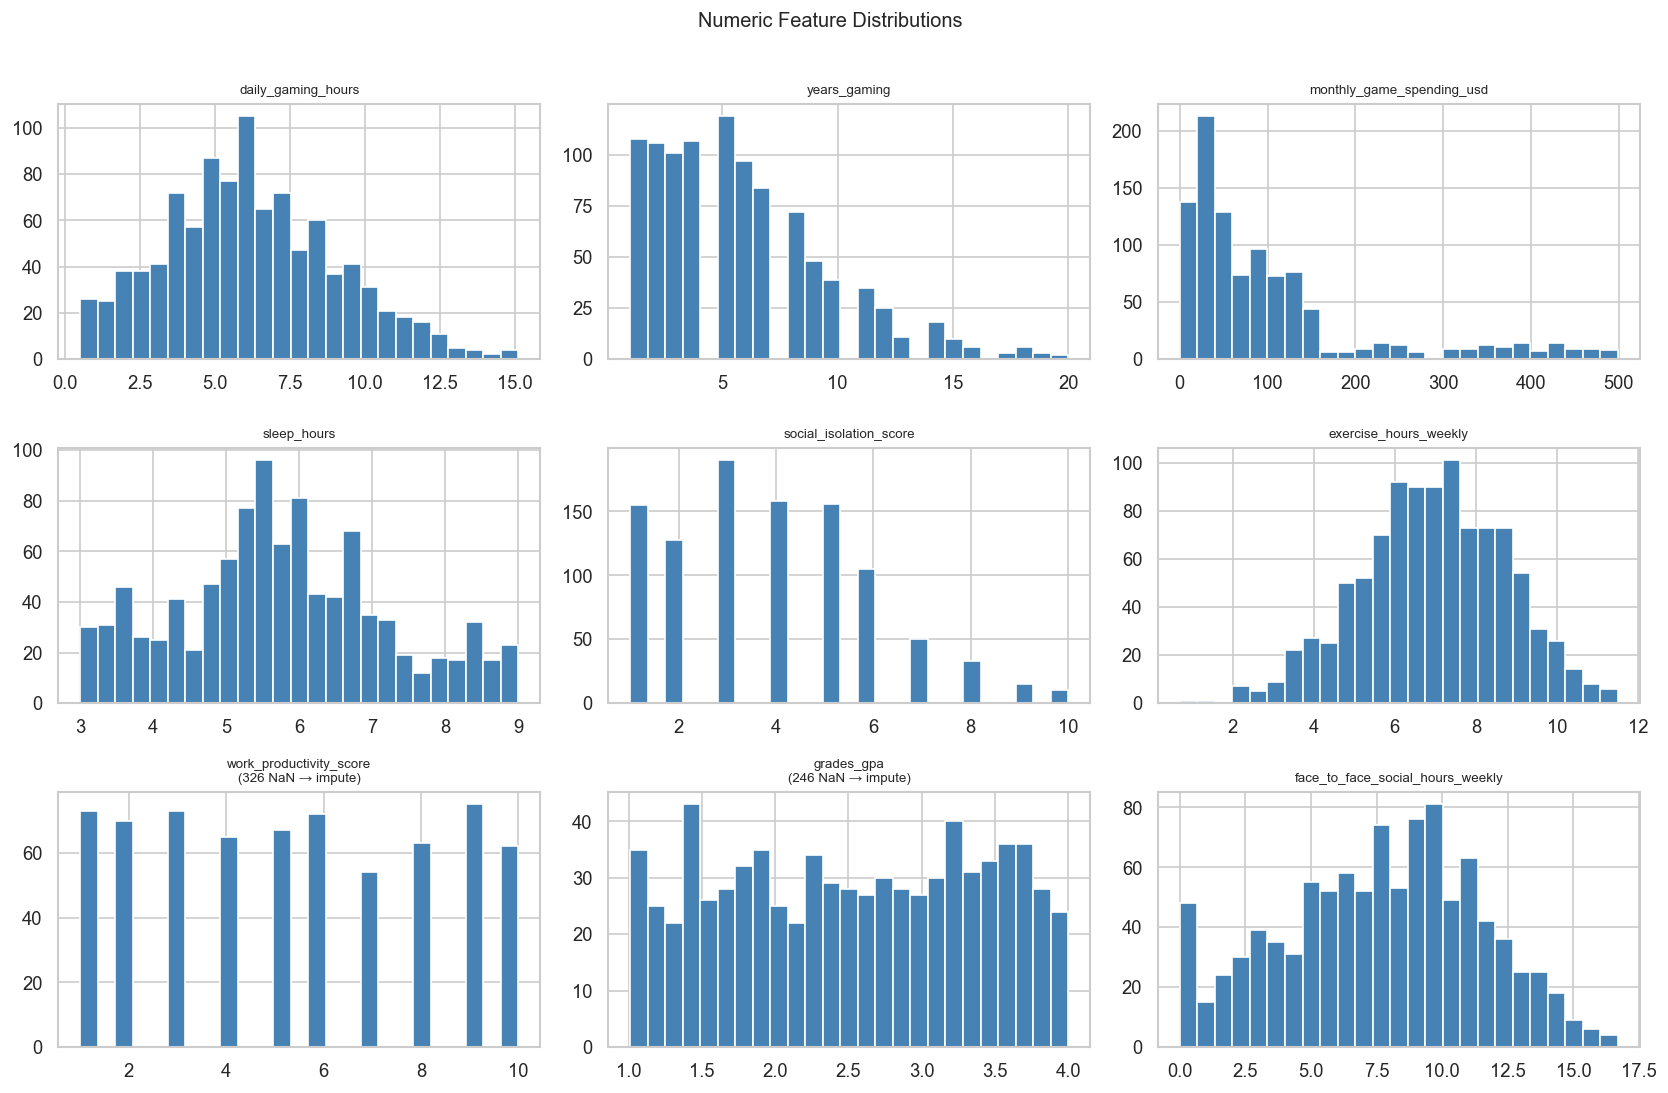

In [6]:
# ── distributions of key numeric features ──────────────────────────────────
num_cols = [
    'daily_gaming_hours', 'years_gaming', 'monthly_game_spending_usd',
    'sleep_hours', 'social_isolation_score', 'exercise_hours_weekly',
    'work_productivity_score', 'grades_gpa', 'face_to_face_social_hours_weekly',
]
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.flat, num_cols):
    data_col = df[col].dropna()
    ax.hist(data_col, bins=25, color='steelblue', edgecolor='white')
    missing_n = df[col].isnull().sum()
    title = col if missing_n == 0 else f'{col}\n({missing_n} NaN → impute)'
    ax.set_title(title, fontsize=8)
plt.suptitle('Numeric Feature Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Audit findings

| Column | Issue | Treatment |
|---|---|---|
| `grades_gpa` | 24.6 % missing | Median imputation |
| `work_productivity_score` | 32.6 % missing | Median imputation |
| `academic_work_performance` | 6 levels incl. `'Failing'` | Ordinal map 0–5 |
| `withdrawal_symptoms` etc. | Native Python `bool` (not string) | `.astype(int)` directly |
| One-hot columns | May have zero variance after encoding | Drop via `VarianceThreshold` |

## 3. Feature Selection

Personas should describe *how* someone games and *how gaming affects their life* —
not *who* they are demographically.

| Group | Features | Rationale |
|---|---|---|
| Behavioral core | `daily_gaming_hours`, `years_gaming`, `monthly_game_spending_usd`, `game_genre`, `gaming_platform`, `gaming_addiction_risk_level` | Defines intensity, investment, play-style |
| Lifestyle impact | `sleep_hours`, `sleep_quality`, `sleep_disruption_frequency`, `social_isolation_score`, `face_to_face_social_hours_weekly`, `exercise_hours_weekly`, `work_productivity_score`, `grades_gpa`, `academic_work_performance` | How gaming ripples into daily life |
| Addiction indicators | `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems` | Clinical addiction signals |

**Excluded:** `record_id` (ID), `age`/`gender` (demographic — would bias clusters toward age bands),
`primary_game` (too granular; genre captures the same signal),
`eye_strain`/`back_neck_pain`/`weight_change_kg` (downstream physical effects, not persona drivers),
`mood_state`/`mood_swing_frequency` (subjective self-report outcome, not a driver).

In [7]:
NUMERIC_FEATURES = [
    'daily_gaming_hours',
    'years_gaming',
    'monthly_game_spending_usd',
    'sleep_hours',
    'social_isolation_score',
    'face_to_face_social_hours_weekly',
    'exercise_hours_weekly',
    'work_productivity_score',   # 32.6 % missing → impute
    'grades_gpa',                # 24.6 % missing → impute
]

# Ordinal: meaningful order exists
ORDINAL_FEATURES = [
    'gaming_addiction_risk_level',
    'sleep_quality',
    'sleep_disruption_frequency',
    'academic_work_performance',
]

# Boolean: native Python bool dtype in this dataset
BOOL_FEATURES = [
    'withdrawal_symptoms',
    'loss_of_other_interests',
    'continued_despite_problems',
]

# Nominal: no implied order → one-hot encode
NOMINAL_FEATURES = [
    'game_genre',
    'gaming_platform',
]

ALL_FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + BOOL_FEATURES + NOMINAL_FEATURES
print(f'Total selected features: {len(ALL_FEATURES)}')
print(f'  Numeric  : {len(NUMERIC_FEATURES)}')
print(f'  Ordinal  : {len(ORDINAL_FEATURES)}')
print(f'  Boolean  : {len(BOOL_FEATURES)}')
print(f'  Nominal  : {len(NOMINAL_FEATURES)}')

Total selected features: 18
  Numeric  : 9
  Ordinal  : 4
  Boolean  : 3
  Nominal  : 2


## 4. Preprocessing

Steps in order:
1. **Impute numeric NaNs** with column median (before any encoding)
2. **Ordinal encode** — integer mapping preserving rank
3. **Boolean cast** — native `bool` → `int` (no mapping needed)
4. **One-hot encode** nominals
5. **Drop zero-variance columns** — OHE can produce all-0 columns whose `std=0` causes `StandardScaler` to output NaN
6. **Scale** — `StandardScaler` (K-Means is Euclidean-distance-based; scale is mandatory)

In [8]:
# ── Step 0: work on a copy ──────────────────────────────────────────────────
raw = df[ALL_FEATURES].copy()
print(f'Starting shape: {raw.shape}')
print(f'Missing values before preprocessing:')
mv = raw.isnull().sum()
print(mv[mv > 0].to_string() if mv.any() else '  None')

Starting shape: (1000, 18)
Missing values before preprocessing:
work_productivity_score    326
grades_gpa                 246


In [9]:
# ── Step 1: Impute numeric NaNs with column median ──────────────────────────
# Done BEFORE encoding so medians are computed on true numeric values.
# Median is robust to the skewed distributions present here (spending, GPA).
num_imputer = SimpleImputer(strategy='median')
raw[NUMERIC_FEATURES] = num_imputer.fit_transform(raw[NUMERIC_FEATURES])

still_missing = raw[NUMERIC_FEATURES].isnull().sum().sum()
print(f'Numeric NaNs after imputation: {still_missing}  ✓' if still_missing == 0
      else f'WARNING: {still_missing} NaNs remain in numeric columns!')

# Confirm medians used
print('\nImputation medians:')
print(pd.Series(num_imputer.statistics_, index=NUMERIC_FEATURES).round(3).to_string())

Numeric NaNs after imputation: 0  ✓

Imputation medians:
daily_gaming_hours                   6.000
years_gaming                         5.000
monthly_game_spending_usd           66.405
sleep_hours                          5.700
social_isolation_score               4.000
face_to_face_social_hours_weekly     8.000
exercise_hours_weekly                7.000
work_productivity_score              5.000
grades_gpa                           2.530


In [10]:
# ── Step 2: Ordinal encode ──────────────────────────────────────────────────
# Each mapping is derived directly from the audit — all observed values are covered.
ORDINAL_MAPS = {
    'gaming_addiction_risk_level': {
        'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3,
    },
    'sleep_quality': {
        'Insomnia': 0, 'Very Poor': 1, 'Poor': 2, 'Fair': 3, 'Good': 4, 'Excellent': 5,
    },
    'sleep_disruption_frequency': {
        'Always': 0, 'Often': 1, 'Sometimes': 2, 'Rarely': 3, 'Never': 4,
    },
    'academic_work_performance': {
        'Failing': 0, 'Poor': 1, 'Below Average': 2,
        'Average': 3, 'Good': 4, 'Excellent': 5,
    },
}

for col, mapping in ORDINAL_MAPS.items():
    # Check for any values NOT covered by the mapping
    actual_vals  = set(raw[col].dropna().unique())
    covered_vals = set(mapping.keys())
    uncovered    = actual_vals - covered_vals
    if uncovered:
        print(f'WARNING [{col}]: unmapped values {uncovered} → will be NaN → imputed with median')
    raw[col] = raw[col].map(mapping)

# Impute any NaNs created by uncovered ordinal values
ord_missing = raw[ORDINAL_FEATURES].isnull().sum()
if ord_missing.any():
    print(f'\nImputing residual ordinal NaNs:')
    print(ord_missing[ord_missing > 0].to_string())
    ord_imputer = SimpleImputer(strategy='median')
    raw[ORDINAL_FEATURES] = ord_imputer.fit_transform(raw[ORDINAL_FEATURES])
else:
    print('Ordinal encoding: all values mapped — no NaNs.  ✓')

Ordinal encoding: all values mapped — no NaNs.  ✓


In [11]:
# ── Step 3: Boolean → int ───────────────────────────────────────────────────
# These columns are native Python bool dtype — .astype(int) is safe and direct.
for col in BOOL_FEATURES:
    assert raw[col].dtype == bool, f'{col} is not bool dtype — check the dataset!'
    raw[col] = raw[col].astype(int)

bool_missing = raw[BOOL_FEATURES].isnull().sum().sum()
print(f'Boolean NaNs after cast: {bool_missing}  ✓' if bool_missing == 0
      else f'WARNING: {bool_missing} boolean NaNs remain!')
print(raw[BOOL_FEATURES].head(3))

Boolean NaNs after cast: 0  ✓
   withdrawal_symptoms  loss_of_other_interests  continued_despite_problems
0                    1                        0                           1
1                    0                        0                           0
2                    1                        1                           1


In [12]:
# ── Step 4: One-Hot Encode nominals ────────────────────────────────────────
encoded = pd.get_dummies(raw, columns=NOMINAL_FEATURES, drop_first=False, dtype=float)
print(f'Shape after OHE: {encoded.shape}  (was {raw.shape})')
print(f'New columns from OHE: {[c for c in encoded.columns if c not in raw.columns]}')

Shape after OHE: (1000, 27)  (was (1000, 18))
New columns from OHE: ['game_genre_Battle Royale', 'game_genre_FPS', 'game_genre_MMO', 'game_genre_MOBA', 'game_genre_Mobile Games', 'game_genre_RPG', 'game_genre_Strategy', 'gaming_platform_Console', 'gaming_platform_Mobile', 'gaming_platform_Multi-platform', 'gaming_platform_PC']


In [13]:
# ── Sanity check: no NaNs at this point ────────────────────────────────────
total_nan = encoded.isnull().sum().sum()
if total_nan > 0:
    print(f'WARNING: {total_nan} NaNs still present before scaling:')
    print(encoded.isnull().sum()[encoded.isnull().sum() > 0].to_string())
    # Final safety net — impute anything remaining
    final_imputer = SimpleImputer(strategy='median')
    encoded = pd.DataFrame(
        final_imputer.fit_transform(encoded),
        columns=encoded.columns
    )
    print('  → Imputed with column medians.')
else:
    print(f'No NaNs before scaling.  ✓')

No NaNs before scaling.  ✓


In [14]:
# ── Step 5: Drop zero-variance columns ─────────────────────────────────────
# OHE can create all-zero columns for rare categories.
# std=0 causes StandardScaler to produce NaN (0/0) — must remove these first.
vt = VarianceThreshold(threshold=0.0)
vt.fit(encoded)
dropped_cols = encoded.columns[~vt.get_support()].tolist()
if dropped_cols:
    print(f'Dropping {len(dropped_cols)} zero-variance column(s): {dropped_cols}')
    encoded = encoded[encoded.columns[vt.get_support()]]
else:
    print('No zero-variance columns found.  ✓')
print(f'Shape after variance filter: {encoded.shape}')

No zero-variance columns found.  ✓
Shape after variance filter: (1000, 27)


In [15]:
# ── Step 6: StandardScaler ─────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(encoded)

# Hard assertion — any NaN here would corrupt PCA and KMeans silently
nan_mask = np.isnan(X_scaled)
if nan_mask.any():
    bad_cols = encoded.columns[nan_mask.any(axis=0)].tolist()
    raise ValueError(f'NaN in X_scaled after scaling — columns: {bad_cols}')

print(f'X_scaled shape : {X_scaled.shape}')
print(f'Any NaN        : {np.isnan(X_scaled).any()}  ✓')
print(f'Feature means  : min={X_scaled.mean(axis=0).min():.4f}, max={X_scaled.mean(axis=0).max():.4f}  (should be ~0)')

X_scaled shape : (1000, 27)
Any NaN        : False  ✓
Feature means  : min=-0.0000, max=0.0000  (should be ~0)


## 5. PCA — Dimensionality Reduction

Why PCA before K-Means:
- Removes noise and multicollinearity (many features are correlated)
- Reduces the curse of dimensionality for Euclidean-distance-based clustering
- Allows 2-D visualisation of clusters

We keep enough components to explain ≥ 80 % of variance (balance between signal retention and noise removal).
A separate 2-component projection is kept purely for plotting.

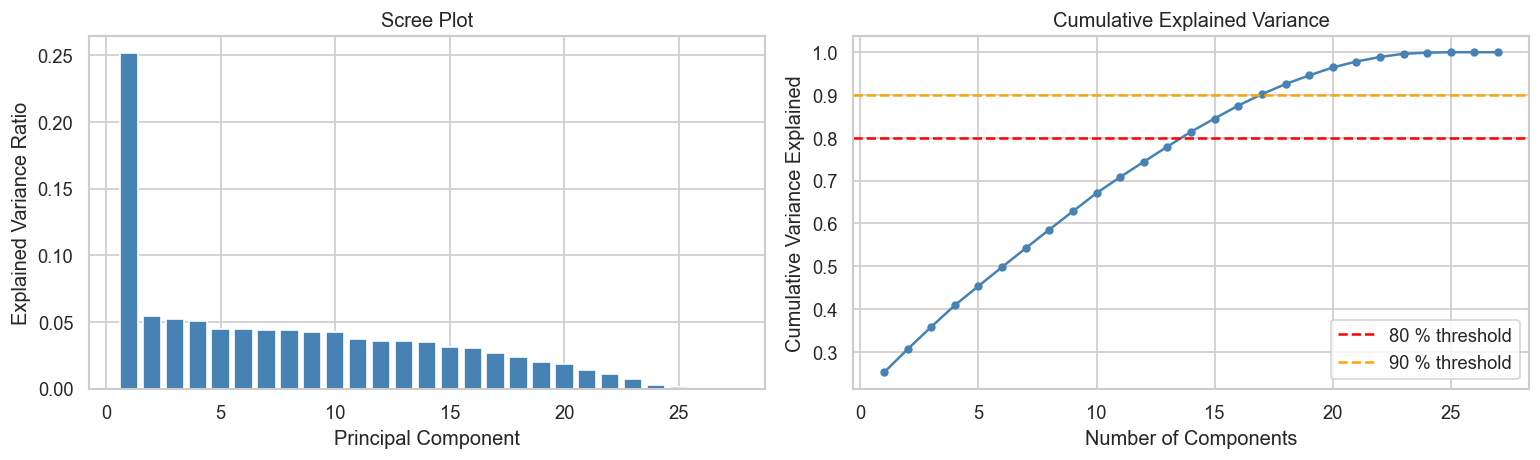

Components for 80 % variance: 14
Components for 90 % variance: 17


In [16]:
# Full PCA to plot explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

# Cumulative
axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o', color='steelblue', markersize=4)
axes[1].axhline(0.80, color='red',    linestyle='--', label='80 % threshold')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90 % threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

n80 = int(np.argmax(cumvar >= 0.80)) + 1
n90 = int(np.argmax(cumvar >= 0.90)) + 1
print(f'Components for 80 % variance: {n80}')
print(f'Components for 90 % variance: {n90}')

In [17]:
# Apply chosen PCA (80 % threshold)
pca    = PCA(n_components=n80, random_state=42)
X_pca  = pca.fit_transform(X_scaled)

# 2-D projection for visualisation only
pca2d  = PCA(n_components=2, random_state=42)
X_2d   = pca2d.fit_transform(X_scaled)

print(f'PCA: {X_scaled.shape[1]} → {X_pca.shape[1]} components  '
      f'({cumvar[n80-1]:.1%} variance retained)')
print(f'2-D projection retains {pca2d.explained_variance_ratio_.sum():.1%} variance (viz only)')

PCA: 27 → 14 components  (81.4% variance retained)
2-D projection retains 30.6% variance (viz only)


## 6. Choosing K

We use two independent signals:
- **Elbow (inertia / WCSS):** look for the kink where additional clusters yield diminishing returns
- **Silhouette score:** measures how well-separated clusters are; higher = better (max = 1.0)

We test K = 2–10 and pick the best K ≥ 4 whose silhouette is within 0.02 of the global maximum
(enforcing interpretable granularity while respecting the data).

In [18]:
k_range      = range(2, 11)
inertias     = []
sil_scores   = []

for k in k_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil    = silhouette_score(X_pca, labels)
    sil_scores.append(sil)
    print(f'K={k:2d} | Inertia: {km.inertia_:9,.1f} | Silhouette: {sil:.4f}')

K= 2 | Inertia:  16,812.6 | Silhouette: 0.2097


K= 3 | Inertia:  15,971.1 | Silhouette: 0.1198


K= 4 | Inertia:  15,089.4 | Silhouette: 0.1371


K= 5 | Inertia:  14,278.7 | Silhouette: 0.1500


K= 6 | Inertia:  13,756.9 | Silhouette: 0.1264


K= 7 | Inertia:  13,041.4 | Silhouette: 0.1841


K= 8 | Inertia:  12,277.8 | Silhouette: 0.2007


K= 9 | Inertia:  11,809.4 | Silhouette: 0.1879


K=10 | Inertia:  11,360.1 | Silhouette: 0.1939


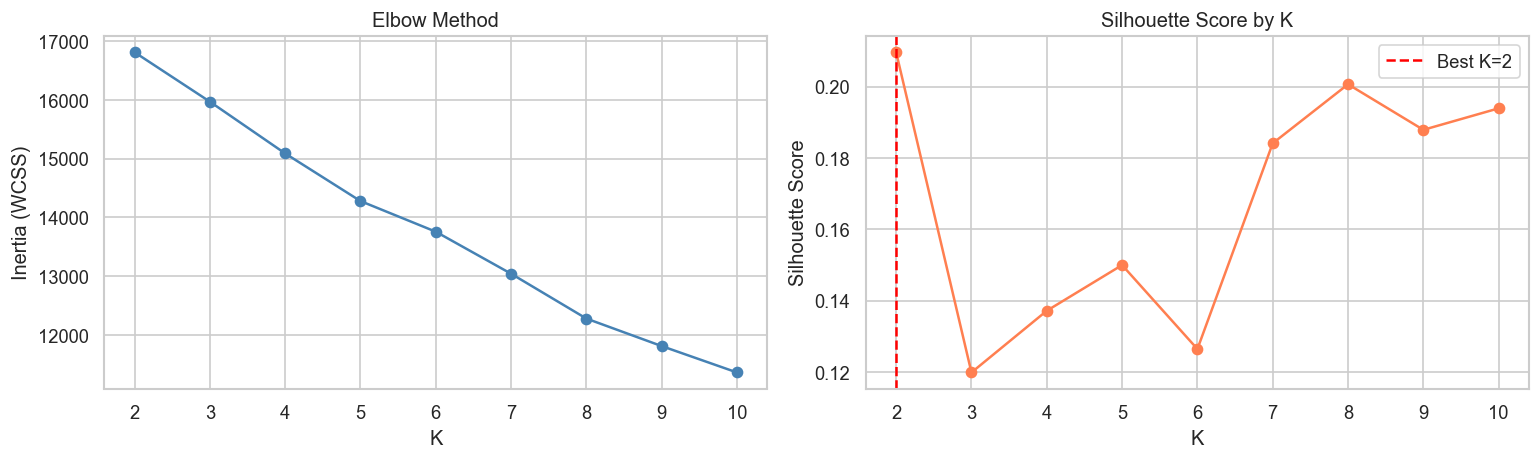

Global best K by silhouette: 2


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

# Silhouette
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
axes[1].plot(list(k_range), sil_scores, marker='o', color='coral')
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Global best K by silhouette: {best_k_sil}')

In [20]:
# Select final K: smallest K >= 4 whose silhouette is within 0.02 of the max.
# If no such K exists (e.g. all high-K scores are far below), fall back to best_k_sil.
max_sil    = max(sil_scores)
candidates = [k for k, s in zip(k_range, sil_scores) if s >= max_sil - 0.02 and k >= 4]
K_FINAL    = min(candidates) if candidates else best_k_sil

print(f'Selected K = {K_FINAL}')
print(f'Silhouette at K={K_FINAL}: {sil_scores[K_FINAL - 2]:.4f}  '
      f'(global max = {max_sil:.4f} at K={best_k_sil})')

Selected K = 8
Silhouette at K=8: 0.2007  (global max = 0.2097 at K=2)


## 7. Fit Final K-Means

- `init='k-means++'` — smarter centroid initialisation, avoids bad local minima
- `n_init=50` — 50 independent random starts; best result kept
- `max_iter=500` — generous iteration budget

In [21]:
km_final = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42,
)
cluster_labels = km_final.fit_predict(X_pca)
df['cluster']  = cluster_labels

final_sil = silhouette_score(X_pca, cluster_labels)
print(f'Final K-Means  K={K_FINAL}')
print(f'Inertia        : {km_final.inertia_:,.1f}')
print(f'Silhouette     : {final_sil:.4f}')
print(f'\nCluster sizes:')
print(pd.Series(cluster_labels).value_counts().sort_index().to_string())

Final K-Means  K=8
Inertia        : 12,277.8
Silhouette     : 0.2007

Cluster sizes:
0    100
1     97
2     93
3    112
4     97
5    280
6    103
7    118


## 8. Cluster Visualisation

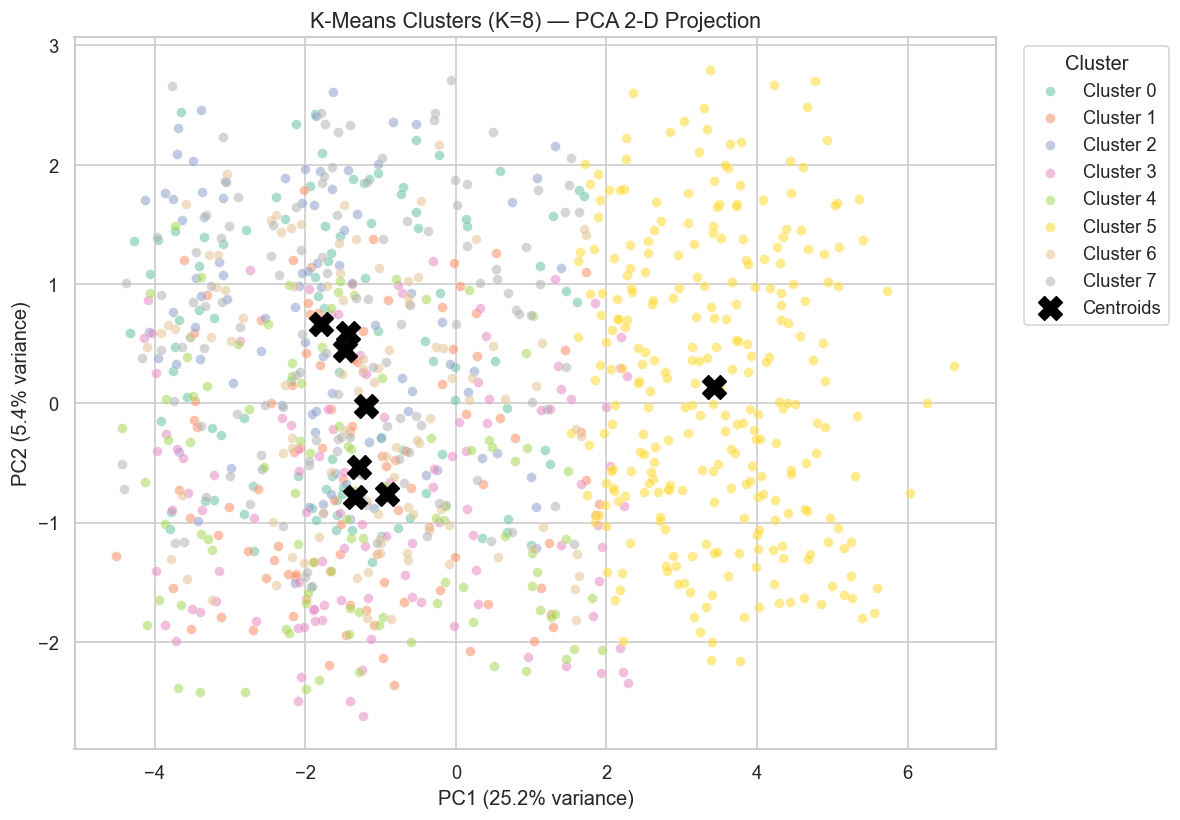

In [22]:
PALETTE = sns.color_palette('Set2', K_FINAL)

# ── 2-D PCA scatter ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
for i in range(K_FINAL):
    mask = cluster_labels == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[PALETTE[i]], label=f'Cluster {i}',
               alpha=0.55, s=35, edgecolors='white', linewidths=0.3)

# Project centroids into 2-D
centroids_orig = scaler.inverse_transform(pca.inverse_transform(km_final.cluster_centers_))
centroids_2d   = pca2d.transform(scaler.transform(centroids_orig))
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'K-Means Clusters (K={K_FINAL}) — PCA 2-D Projection', fontsize=13)
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

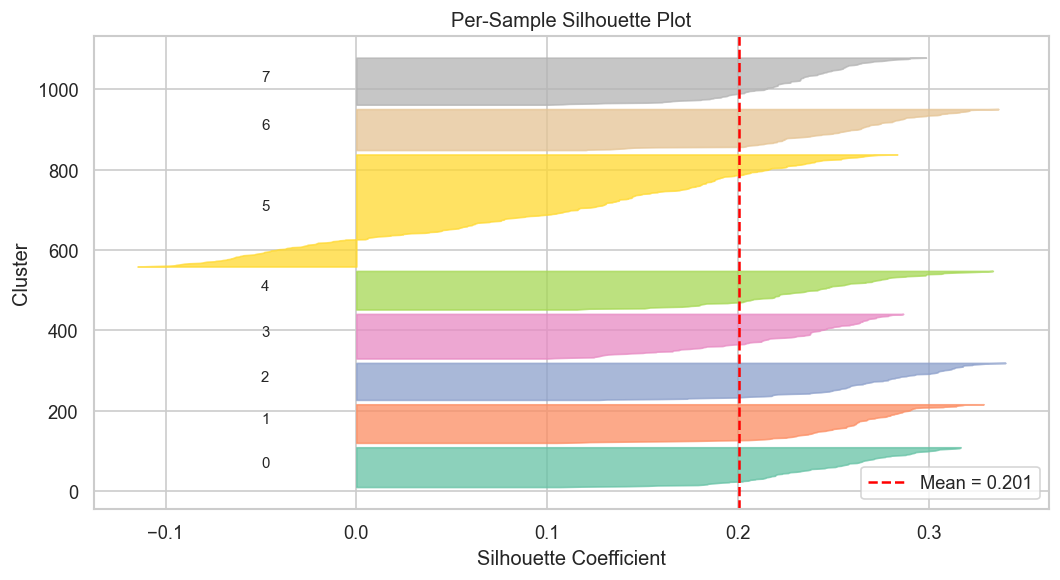

In [23]:
# ── Silhouette plot per sample ───────────────────────────────────────────────
sample_sil = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in range(K_FINAL):
    vals    = np.sort(sample_sil[cluster_labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=PALETTE[i], edgecolor=PALETTE[i], alpha=0.75)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(final_sil, color='red', linestyle='--', label=f'Mean = {final_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Per-Sample Silhouette Plot')
ax.legend()
plt.tight_layout()
plt.show()

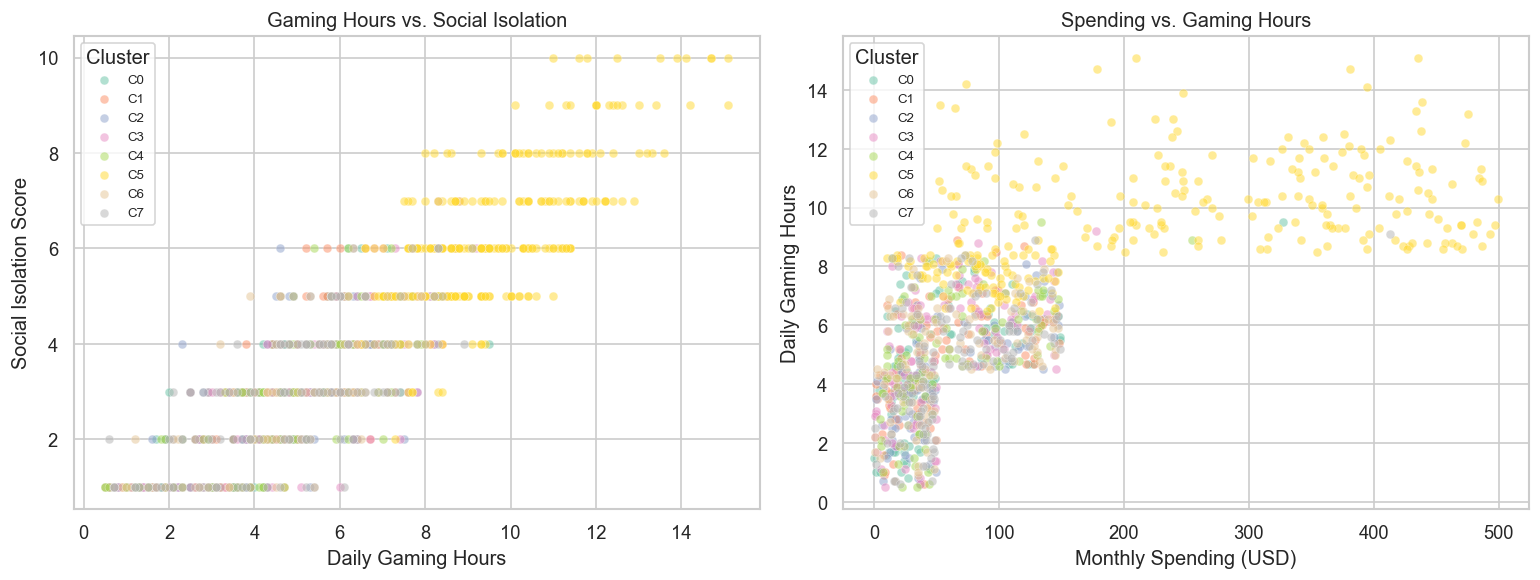

In [24]:
# ── Gaming hours vs social isolation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i in range(K_FINAL):
    mask = df['cluster'] == i
    axes[0].scatter(df.loc[mask, 'daily_gaming_hours'],
                    df.loc[mask, 'social_isolation_score'],
                    c=[PALETTE[i]], label=f'C{i}', alpha=0.5, s=28,
                    edgecolors='white', linewidths=0.3)
    axes[1].scatter(df.loc[mask, 'monthly_game_spending_usd'],
                    df.loc[mask, 'daily_gaming_hours'],
                    c=[PALETTE[i]], label=f'C{i}', alpha=0.5, s=28,
                    edgecolors='white', linewidths=0.3)

axes[0].set(xlabel='Daily Gaming Hours', ylabel='Social Isolation Score',
            title='Gaming Hours vs. Social Isolation')
axes[0].legend(title='Cluster', fontsize=8)
axes[1].set(xlabel='Monthly Spending (USD)', ylabel='Daily Gaming Hours',
            title='Spending vs. Gaming Hours')
axes[1].legend(title='Cluster', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Persona Profiling

We profile each cluster on the **original unscaled values** so the numbers are interpretable.
The heatmap uses z-scores relative to other clusters so you can instantly see which cluster
is high or low on each dimension.

In [25]:
PROFILE_NUM = [
    'daily_gaming_hours', 'years_gaming', 'monthly_game_spending_usd',
    'sleep_hours', 'social_isolation_score', 'exercise_hours_weekly',
    'work_productivity_score', 'grades_gpa', 'face_to_face_social_hours_weekly',
]

# Re-encode booleans for mean computation
df_profile = df.copy()
for col in BOOL_FEATURES:
    df_profile[col + '_int'] = df_profile[col].astype(str).str.upper().map(
        {'TRUE': 1, 'FALSE': 0}
    ).fillna(0).astype(int)

bool_int_cols = [c + '_int' for c in BOOL_FEATURES]

numeric_profile = df_profile.groupby('cluster')[PROFILE_NUM].mean().round(2)
bool_profile    = df_profile.groupby('cluster')[bool_int_cols].mean().round(3)
bool_profile.columns = BOOL_FEATURES

full_profile = pd.concat([numeric_profile, bool_profile], axis=1)
print('=== Cluster Profiles (original-scale means) ===')
full_profile

=== Cluster Profiles (original-scale means) ===


,daily_gaming_hours,years_gaming,monthly_game_spending_usd,sleep_hours,social_isolation_score,exercise_hours_weekly,work_productivity_score,grades_gpa,face_to_face_social_hours_weekly,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems
cluster,,,,,,,,,,,,
0,4.66,5.93,57.37,6.27,2.93,7.72,4.93,2.48,9.70,0.060,0.250,0.010
1,4.83,5.79,55.51,6.25,2.98,7.52,5.09,2.50,9.36,0.113,0.186,0.010
2,4.32,6.18,55.39,6.57,2.63,7.90,5.28,2.44,9.41,0.043,0.151,0.011
3,5.22,5.59,57.50,5.96,3.14,7.37,5.26,2.52,8.81,0.223,0.268,0.009
4,4.82,6.06,56.79,6.09,2.89,7.86,4.88,2.55,9.40,0.124,0.175,0.000
5,9.59,5.58,224.48,4.47,6.26,5.20,5.62,2.54,3.47,0.743,0.611,0.475
6,4.91,5.88,60.89,6.28,3.08,7.35,5.79,2.48,9.03,0.087,0.252,0.010
7,4.84,5.79,66.71,6.23,2.91,7.72,5.73,2.59,9.34,0.110,0.195,0.008


In [26]:
# Dominant genre and platform per cluster
print('=== Dominant Genre & Platform per Cluster ===')
for cid in sorted(df['cluster'].unique()):
    sub      = df[df['cluster'] == cid]
    genre    = sub['game_genre'].mode()[0]
    platform = sub['gaming_platform'].mode()[0]
    n        = len(sub)
    print(f'  Cluster {cid} (n={n:4d}) | Genre: {genre:20s} | Platform: {platform}')

=== Dominant Genre & Platform per Cluster ===
  Cluster 0 (n= 100) | Genre: RPG                  | Platform: Multi-platform
  Cluster 1 (n=  97) | Genre: Battle Royale        | Platform: Console
  Cluster 2 (n=  93) | Genre: FPS                  | Platform: Mobile
  Cluster 3 (n= 112) | Genre: Mobile Games         | Platform: PC
  Cluster 4 (n=  97) | Genre: Strategy             | Platform: PC
  Cluster 5 (n= 280) | Genre: RPG                  | Platform: Multi-platform
  Cluster 6 (n= 103) | Genre: MMO                  | Platform: Mobile
  Cluster 7 (n= 118) | Genre: MOBA                 | Platform: Mobile


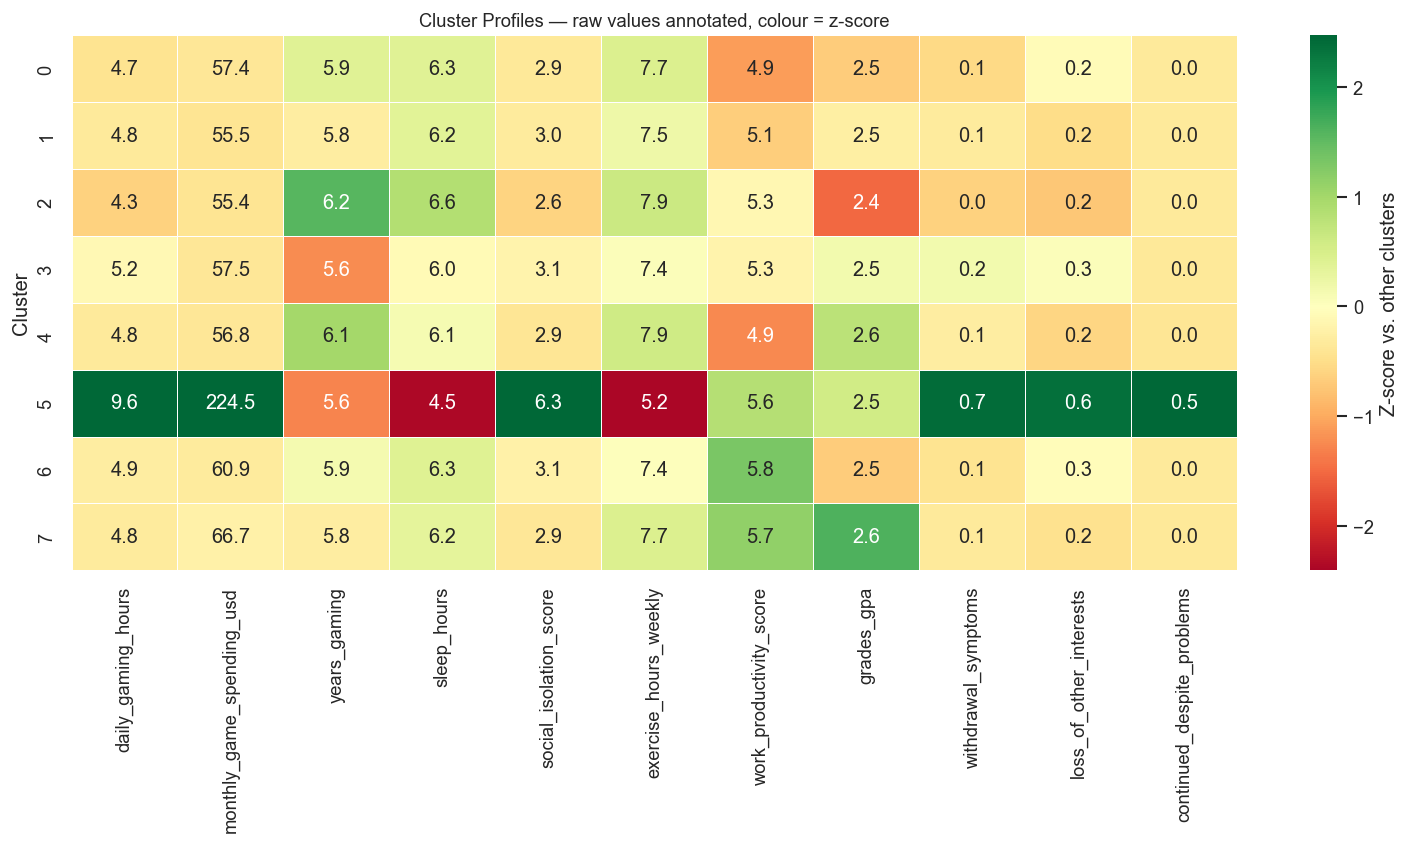

In [27]:
# ── Feature heatmap (z-scored across clusters) ───────────────────────────────
hmap_cols = [
    'daily_gaming_hours', 'monthly_game_spending_usd', 'years_gaming',
    'sleep_hours', 'social_isolation_score', 'exercise_hours_weekly',
    'work_productivity_score', 'grades_gpa',
    'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems',
]
hmap_data = full_profile[hmap_cols]
hmap_z    = (hmap_data - hmap_data.mean()) / (hmap_data.std() + 1e-9)

fig, ax = plt.subplots(figsize=(13, max(3, K_FINAL * 0.9)))
sns.heatmap(
    hmap_z,
    annot=hmap_data.round(1),
    fmt='',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Z-score vs. other clusters'},
)
ax.set_title('Cluster Profiles — raw values annotated, colour = z-score', fontsize=11)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

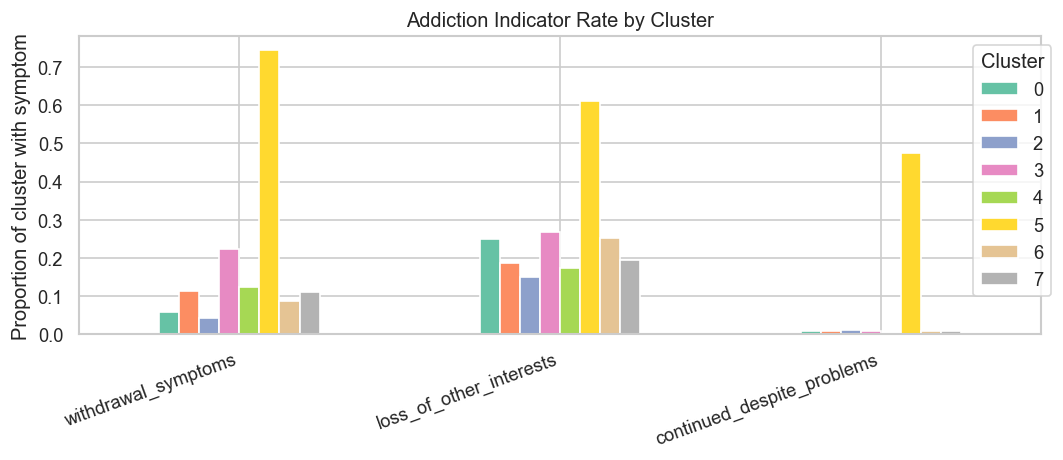

In [28]:
# ── Addiction indicator rates ────────────────────────────────────────────────
bool_profile.T.plot(
    kind='bar', figsize=(9, 4), colormap='Set2', edgecolor='white'
)
plt.title('Addiction Indicator Rate by Cluster')
plt.ylabel('Proportion of cluster with symptom')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 10. Persona Naming

**Naming priority:**
1. **Tier 1 — extreme behavioral signals** (addiction / spending / hours) override everything else
2. **Tier 2 — genre + platform identity** (most clusters are driven by play-style combination)
3. **Tier 3 — lifestyle fallback** for any cluster that doesn't match the above

Tier 2 is intentionally placed before lifestyle rules because the audit showed that
genre/platform is the primary cluster driver for most non-extreme clusters.

In [29]:
def assign_persona(row, gmeans, genre, platform):
    """
    Assign a descriptive persona name to a cluster based on its mean feature profile.

    Parameters
    ----------
    row    : Series — cluster mean values
    gmeans : Series — dataset-wide mean values (same index)
    genre  : str    — dominant game genre for this cluster
    platform : str  — dominant gaming platform for this cluster
    """
    hrs    = row['daily_gaming_hours']
    spend  = row['monthly_game_spending_usd']
    iso    = row['social_isolation_score']
    prod   = row['work_productivity_score']
    ex     = row['exercise_hours_weekly']
    add    = row[BOOL_FEATURES].mean()   # mean of 3 addiction indicators

    g_hrs   = gmeans['daily_gaming_hours']
    g_spend = gmeans['monthly_game_spending_usd']
    g_iso   = gmeans['social_isolation_score']
    g_prod  = gmeans['work_productivity_score']
    g_ex    = gmeans['exercise_hours_weekly']

    # ── Tier 1: extreme behavioral clusters ──────────────────────────────────
    if add >= 0.6 or (hrs > g_hrs * 1.5 and spend > g_spend * 2.5):
        return 'The Addicted Escapist'
    if hrs > g_hrs * 1.3 and iso > g_iso * 1.2 and prod < g_prod:
        return 'The Hardcore Recluse'
    if spend > g_spend * 1.5 and hrs > g_hrs:
        return 'The Whale Spender'

    # ── Tier 2: genre + platform identity ────────────────────────────────────
    GENRE_PLATFORM = {
        ('RPG',           'Multi-platform'): 'The Multi-Platform RPG Explorer',
        ('Battle Royale', 'Console'):        'The Console Battle Royale Fan',
        ('Strategy',      'Mobile'):         'The Mobile Strategist',
        ('FPS',           'Mobile'):         'The Mobile Shooter',
        ('MOBA',          'Mobile'):         'The Mobile MOBA Grinder',
        ('MMO',           'Mobile'):         'The Mobile MMO Adventurer',
        ('Mobile Games',  'PC'):             'The Crossover Mobile Gamer',
        ('Strategy',      'PC'):             'The PC Strategist',
        ('FPS',           'PC'):             'The PC Shooter',
        ('RPG',           'PC'):             'The PC RPG Fan',
        ('MOBA',          'PC'):             'The PC MOBA Player',
        ('MMO',           'PC'):             'The PC MMO Raider',
        ('Battle Royale', 'Mobile'):         'The Mobile Battle Royale Fan',
        ('Mobile Games',  'Mobile'):         'The Dedicated Mobile Gamer',
        ('Mobile Games',  'Console'):        'The Console Casual',
    }
    key = (genre, platform)
    if key in GENRE_PLATFORM:
        return GENRE_PLATFORM[key]

    # ── Tier 3: lifestyle fallback ────────────────────────────────────────────
    if hrs < g_hrs * 0.85 and prod >= g_prod and ex >= g_ex:
        return 'The Balanced Casual'
    if iso < g_iso * 0.85 and prod >= g_prod:
        return 'The Social Gamer'

    # Ultimate fallback — still descriptive
    return f'The {platform} {genre} Player'


# ── Compute global means on original df ──────────────────────────────────────
gmeans = df[PROFILE_NUM + BOOL_FEATURES].copy()
for col in BOOL_FEATURES:
    gmeans[col] = gmeans[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0}).fillna(0)
gmeans = gmeans.mean()

# ── Assign names ─────────────────────────────────────────────────────────────
persona_map = {}
for cid, row in full_profile.iterrows():
    sub      = df[df['cluster'] == cid]
    genre    = sub['game_genre'].mode()[0]
    platform = sub['gaming_platform'].mode()[0]
    persona_map[cid] = assign_persona(row, gmeans, genre, platform)

# Deduplicate — append #1/#2 if two clusters share a name
name_counts = Counter(persona_map.values())
seen = {}
for cid in sorted(persona_map):
    name = persona_map[cid]
    if name_counts[name] > 1:
        seen[name] = seen.get(name, 0) + 1
        persona_map[cid] = f'{name} #{seen[name]}'

print('=== Gamer Persona Assignments ===')
for cid, name in persona_map.items():
    n = (df['cluster'] == cid).sum()
    print(f'  Cluster {cid} (n={n:4d}): {name}')

df['persona'] = df['cluster'].map(persona_map)

=== Gamer Persona Assignments ===
  Cluster 0 (n= 100): The Multi-Platform RPG Explorer
  Cluster 1 (n=  97): The Console Battle Royale Fan
  Cluster 2 (n=  93): The Mobile Shooter
  Cluster 3 (n= 112): The Crossover Mobile Gamer
  Cluster 4 (n=  97): The PC Strategist
  Cluster 5 (n= 280): The Addicted Escapist
  Cluster 6 (n= 103): The Mobile MMO Adventurer
  Cluster 7 (n= 118): The Mobile MOBA Grinder


In [30]:
# ── Summary table ────────────────────────────────────────────────────────────
summary_cols = [
    'daily_gaming_hours', 'years_gaming', 'monthly_game_spending_usd',
    'sleep_hours', 'social_isolation_score', 'exercise_hours_weekly',
    'work_productivity_score', 'grades_gpa',
]
persona_summary = df.groupby('persona')[summary_cols].mean().round(2)
persona_summary.insert(0, 'n', df.groupby('persona').size())
persona_summary

,n,daily_gaming_hours,years_gaming,monthly_game_spending_usd,sleep_hours,social_isolation_score,exercise_hours_weekly,work_productivity_score,grades_gpa
persona,,,,,,,,,
The Addicted Escapist,280,9.59,5.58,224.48,4.47,6.26,5.20,5.62,2.54
The Console Battle Royale Fan,97,4.83,5.79,55.51,6.25,2.98,7.52,5.09,2.50
The Crossover Mobile Gamer,112,5.22,5.59,57.50,5.96,3.14,7.37,5.26,2.52
The Mobile MMO Adventurer,103,4.91,5.88,60.89,6.28,3.08,7.35,5.79,2.48
The Mobile MOBA Grinder,118,4.84,5.79,66.71,6.23,2.91,7.72,5.73,2.59
The Mobile Shooter,93,4.32,6.18,55.39,6.57,2.63,7.90,5.28,2.44
The Multi-Platform RPG Explorer,100,4.66,5.93,57.37,6.27,2.93,7.72,4.93,2.48
The PC Strategist,97,4.82,6.06,56.79,6.09,2.89,7.86,4.88,2.55


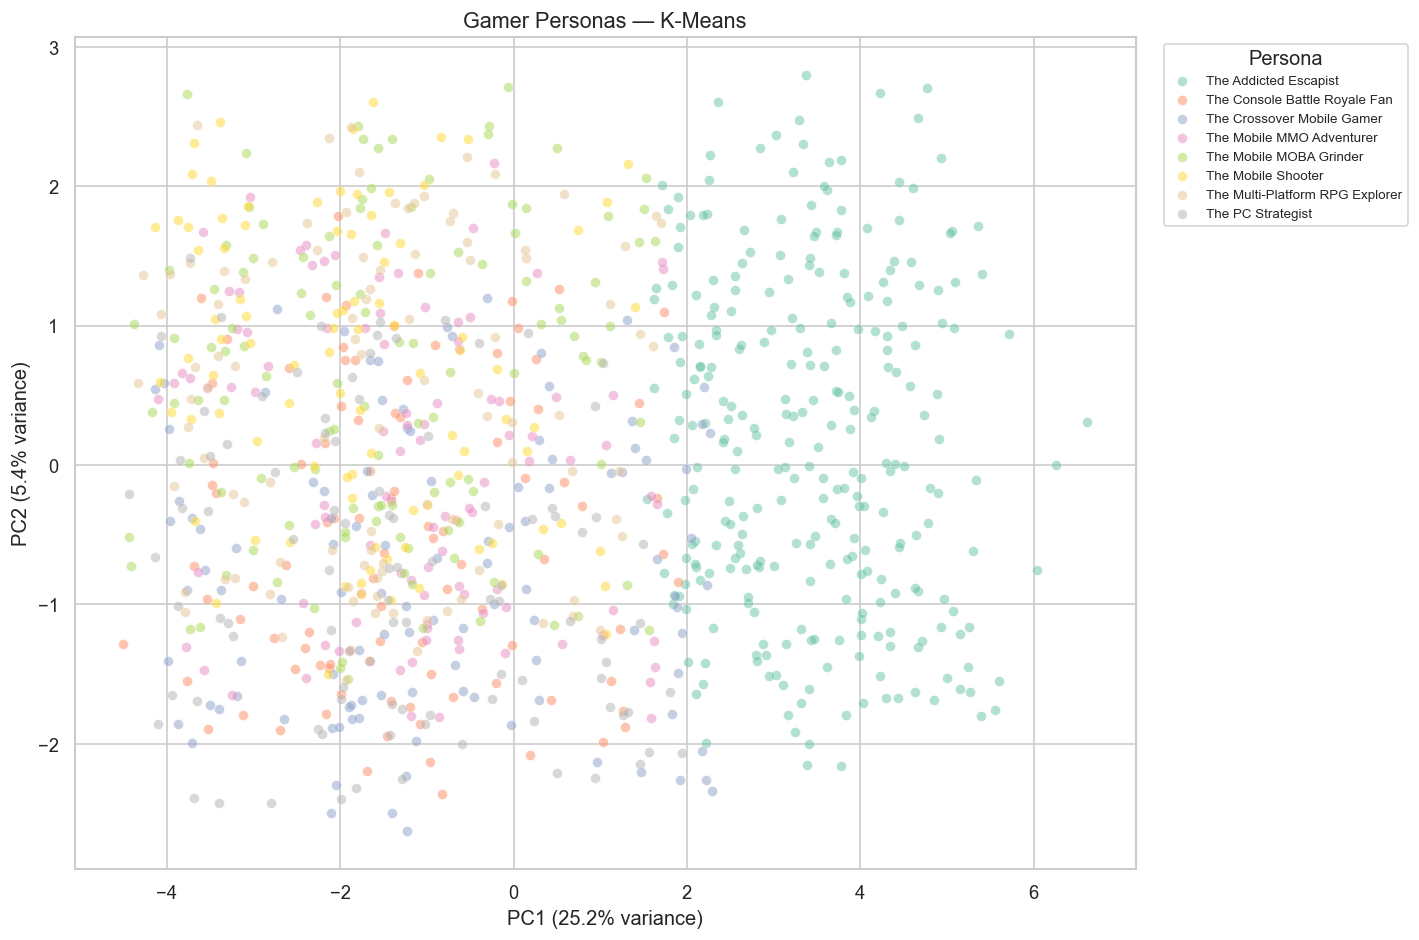

In [31]:
# ── Named persona scatter ─────────────────────────────────────────────────────
unique_personas   = sorted(df['persona'].unique())
persona_palette   = dict(zip(unique_personas, sns.color_palette('Set2', len(unique_personas))))

fig, ax = plt.subplots(figsize=(12, 8))
for persona in unique_personas:
    idx = df.index[df['persona'] == persona]
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
               c=[persona_palette[persona]], label=persona,
               alpha=0.5, s=35, edgecolors='white', linewidths=0.3)

ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Gamer Personas — K-Means', fontsize=13)
ax.legend(title='Persona', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

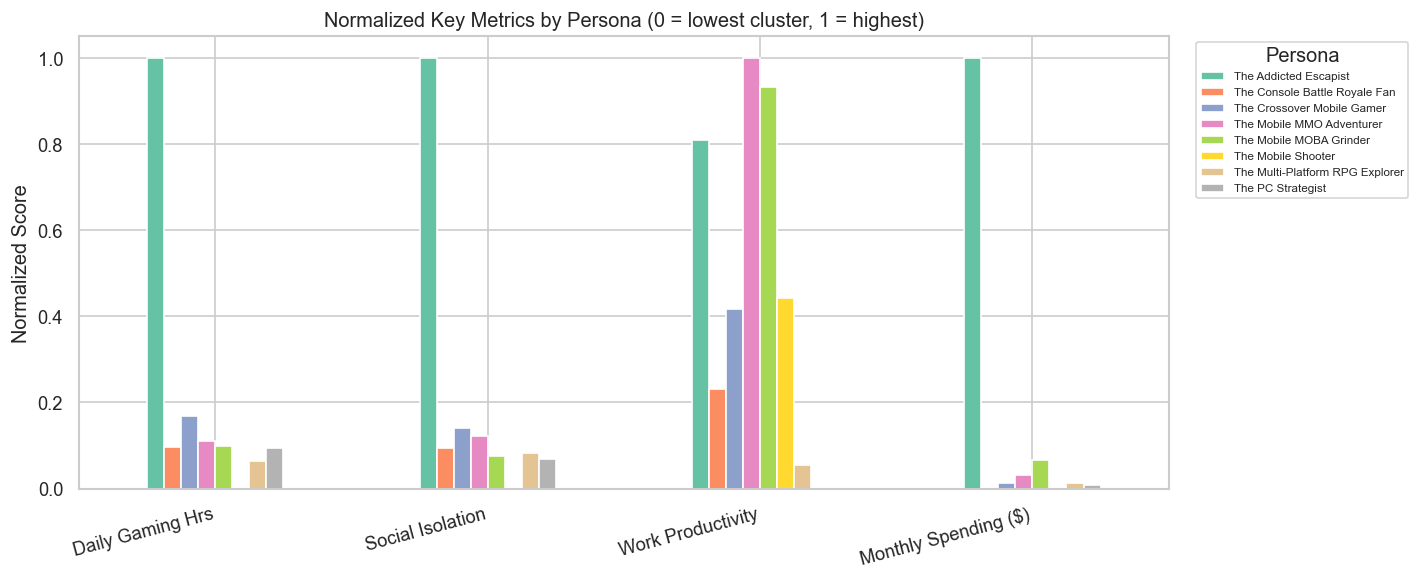

In [32]:
# ── Normalized bar chart: key metrics per persona ────────────────────────────
bar_metrics = [
    'daily_gaming_hours', 'social_isolation_score',
    'work_productivity_score', 'monthly_game_spending_usd',
]
bar_labels = ['Daily Gaming Hrs', 'Social Isolation', 'Work Productivity', 'Monthly Spending ($)']

persona_bar      = df.groupby('persona')[bar_metrics].mean()
persona_bar_norm = (persona_bar - persona_bar.min()) / (persona_bar.max() - persona_bar.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
persona_bar_norm.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_xticklabels(bar_labels, rotation=15, ha='right')
ax.set_title('Normalized Key Metrics by Persona (0 = lowest cluster, 1 = highest)')
ax.set_ylabel('Normalized Score')
ax.legend(title='Persona', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## Summary

### Pipeline recap

| Step | Choice | Why |
|---|---|---|
| Missing values | Median imputation (`SimpleImputer`) before encoding | `grades_gpa` (24.6 %) and `work_productivity_score` (32.6 %) had true NaNs; median is robust to skew |
| Ordinal encoding | Integer mapping covering all 6 levels of `academic_work_performance` incl. `'Failing'` | Preserves rank signal; avoids inflating dimensionality |
| Boolean encoding | `.astype(int)` directly on native `bool` columns | No string conversion needed; safe and exact |
| Zero-variance drop | `VarianceThreshold(0.0)` | One-hot columns with std=0 cause `StandardScaler` to output NaN |
| Scaling | `StandardScaler` | K-Means is Euclidean — unscaled features with large ranges dominate |
| Dimensionality | PCA @ 80 % variance | Removes noise, reduces curse of dimensionality |
| K selection | Elbow + Silhouette, best K ≥ 4 | Two independent signals; enforces interpretable granularity |
| Algorithm | K-Means++ (n_init=50) | Smarter init + many restarts for global stability |
| Naming tier order | Extreme behavior → genre/platform → lifestyle | Genre/platform before lifestyle: audit showed play-style is the primary cluster driver |

### Limitations & next steps
- K-Means assumes spherical clusters — **DBSCAN** or **Gaussian Mixture Models** could capture elongated shapes
- Personas are correlational, not causal — they describe patterns, not why someone became that persona
- **Next step:** train a Random Forest classifier on `persona` to rank feature importances and validate cluster structure